# **Beslutningstrær og random forests**
Disse kode-snuttene er ment som seminar-opplegget som tar for seg ensemble-teknikker.

In [36]:
# Må kanskje kjøres, om dere ikke har gjort det før.
!pip install ISLP

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# 🏙️ Boston-datasettet (ISLP)

**Boston-datasettet** er et klassisk regresjonsdatasett som opprinnelig stammer fra en studie av boligmarkedet i Boston-området på 1970-tallet.  
Det brukes mye i **ISLP-boka (Introduction to Statistical Learning / ISLP)** for å illustrere forskjeller mellom statistiske læringsmetoder.

---

## 🎯 Formål

Målet er å **predikere boligpriser** basert på sosioøkonomiske, geografiske og miljømessige forklaringsvariabler.

- **Responsvariabel**
  
  $$
  Y = \texttt{medv}$$
  
  Median boligverdi (i tusen dollar)

Dette er et klassisk **prediksjonsproblem**, ikke primært et inferensproblem.

---

## 📊 Forklaringsvariabler (X)

Datasettet inneholder **13 forklaringsvariabler**, blant annet:

| Variabel | Forklaring |
|--------|-----------|
| `lstat` | Andel lavinntekts-husholdninger |
| `rm` | Gjennomsnittlig antall rom per bolig |
| `nox` | Luftforurensning |
| `crim` | Kriminalitetsrate |
| `dis` | Avstand til arbeidsplasser |
| `tax` | Eiendomsskatt |
| `ptratio` | Elev–lærer-forhold |
| `chas` | Om området grenser til Charles River |

Mange av disse variablene har **ikke-lineære effekter** og **interaksjoner**, noe som gjør datasettet velegnet for fleksible modeller som beslutningstrær og random forests.


In [38]:
# Last Boston-datasettet
Boston = load_data("Boston")

X = Boston.drop(columns="medv")
y = Boston["medv"]

# Train / test-splitt (70% treningsdata, 30% test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [40]:
X.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


In [41]:
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


# Lineær regresjon på problemet

- Antar lineære sammenhenger, høy bias
- Klarer ikke fange ikke-lineære sammenhenger
- Fører ofte til **underfitting**

Brukes som et naturlig **referansepunkt**.

# Èn variabel
Vi lager lineær regresjon med et prediktor, hvor vi bruker `tax`.

In [43]:
lin_reg = LinearRegression() # Henter inn pakke for lineær regresjon
lin_reg.fit(X_train[['tax']], y_train) # Trener lin. reg modellen vår

# Predikerer på usett, test data
y_pred_lr = lin_reg.predict(X_test[['tax']])

# Evaluerer modellen (vha MSE)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Printer mse
mse_lr

67.1421833881659

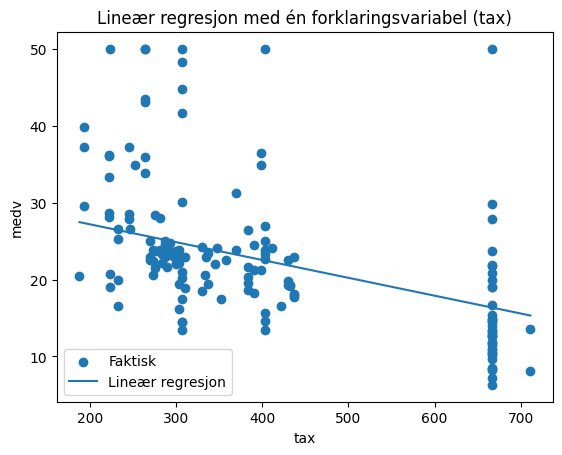

In [45]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.argsort(X_test['tax'])
x_sorted = X_test['tax'].iloc[idx]
y_pred_sorted = y_pred_lr[idx]

plt.figure()
plt.scatter(X_test['tax'], y_test, label="Faktisk")
plt.plot(x_sorted, y_pred_sorted, label="Lineær regresjon")
plt.xlabel("tax")
plt.ylabel("medv")
plt.legend()
plt.title("Lineær regresjon med én forklaringsvariabel (tax)")
plt.show()

# Flere variabler
Multippel lineær regresjon

In [46]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

mse_lr

20.881780202614777

# Beslutningstrær
Vi prøver nå å lage et beslutningstre, med samme formål - predikere `medv`.

In [56]:
tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=1
)

# Trene treet (binary recursive splitting, feature space)
tree.fit(X_train, y_train)

# Predikerer på usett, test data
y_pred_tree = tree.predict(X_test)

# Evaluerer modellen vår
mse_tree = mean_squared_error(y_test, y_pred_tree)

mse_tree

12.401831739709166

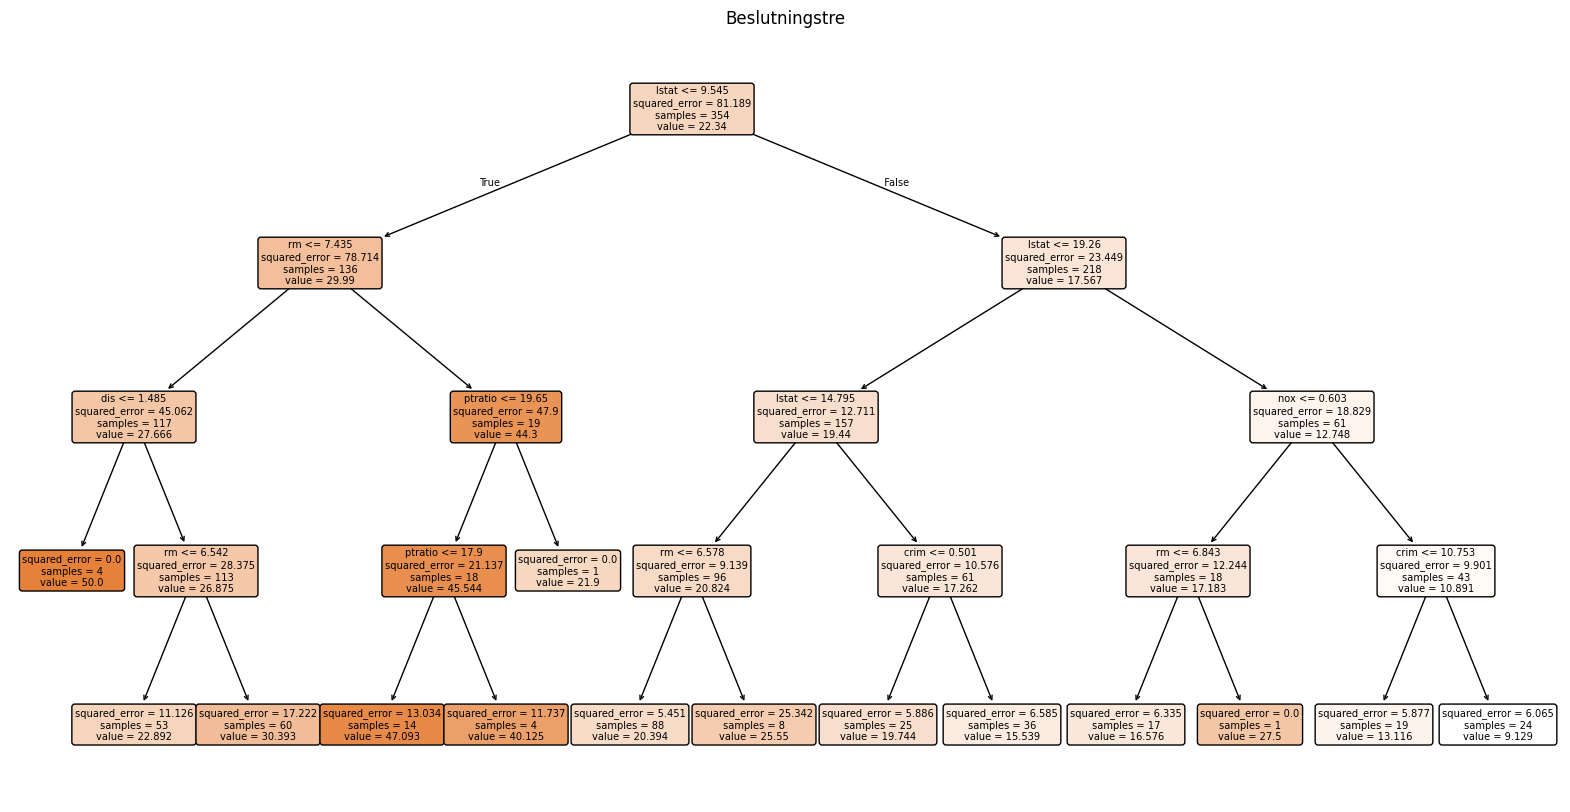

In [57]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.title("Beslutningstre")
plt.show()

# Ensemble learning - Random forests

In [59]:
# Vi lager en ensemble av trær, hvor B = 500
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=1
)

# Trener vår RF-modell
rf.fit(X_train, y_train)

# Predikerer på usett, test data
y_pred_rf = rf.predict(X_test)

# Evaluerer modellen
mse_rf = mean_squared_error(y_test, y_pred_rf)

mse_rf


8.47495273355261

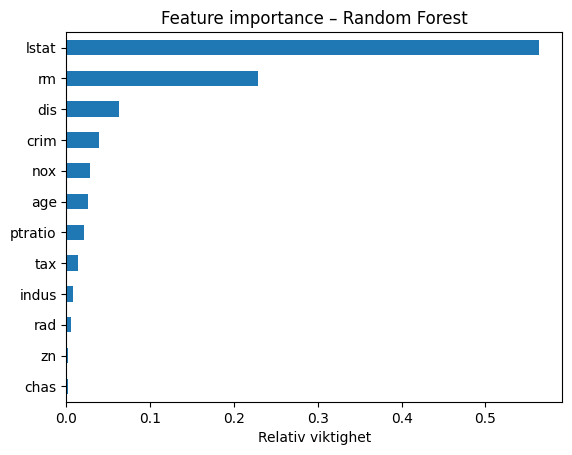

In [60]:
import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure()
importances.plot(kind="barh")
plt.title("Feature importance – Random Forest")
plt.xlabel("Relativ viktighet")
plt.show()

# Visualisere RF

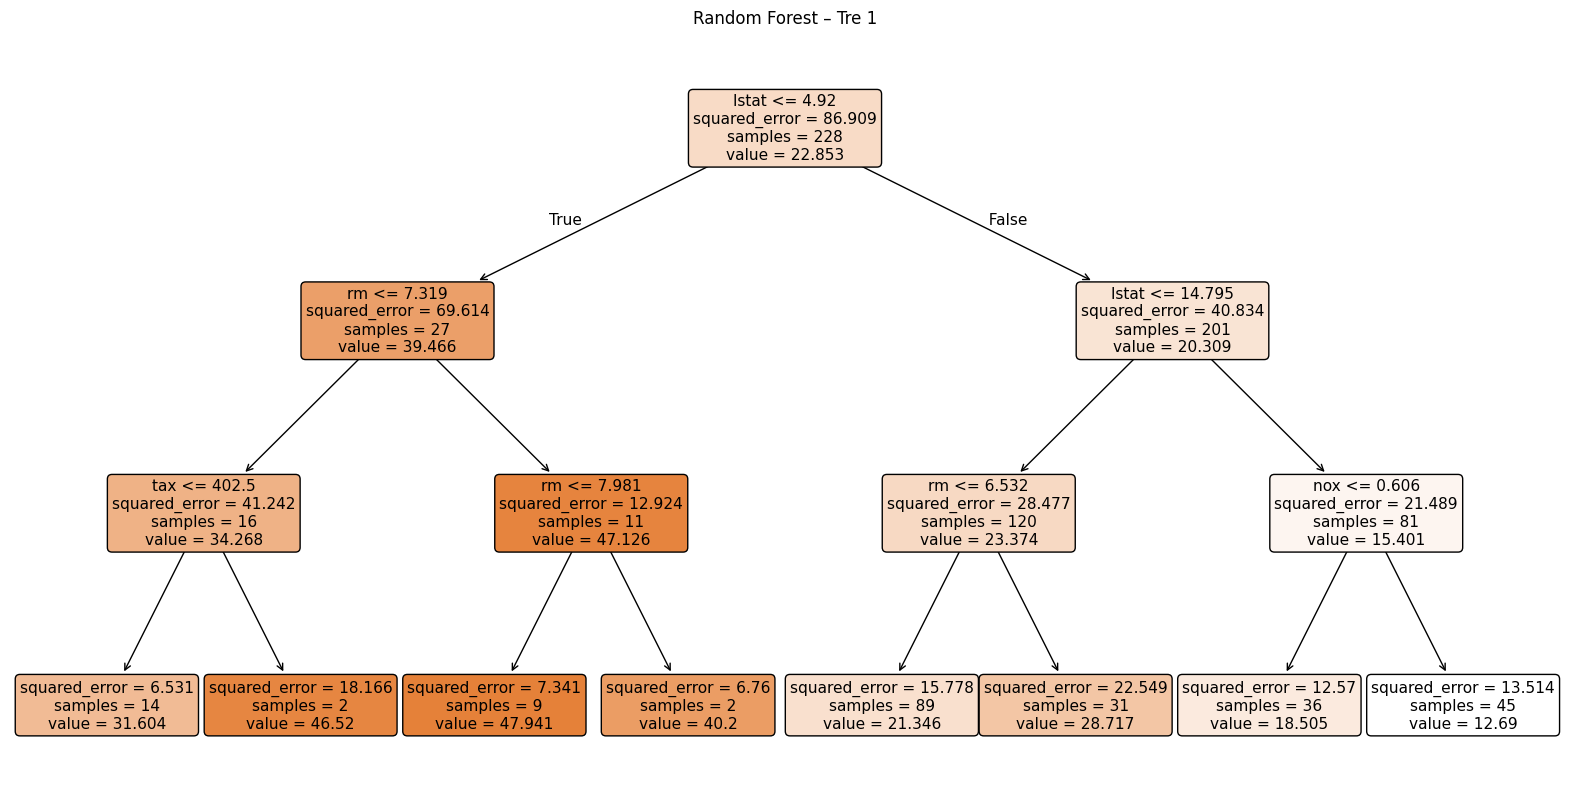

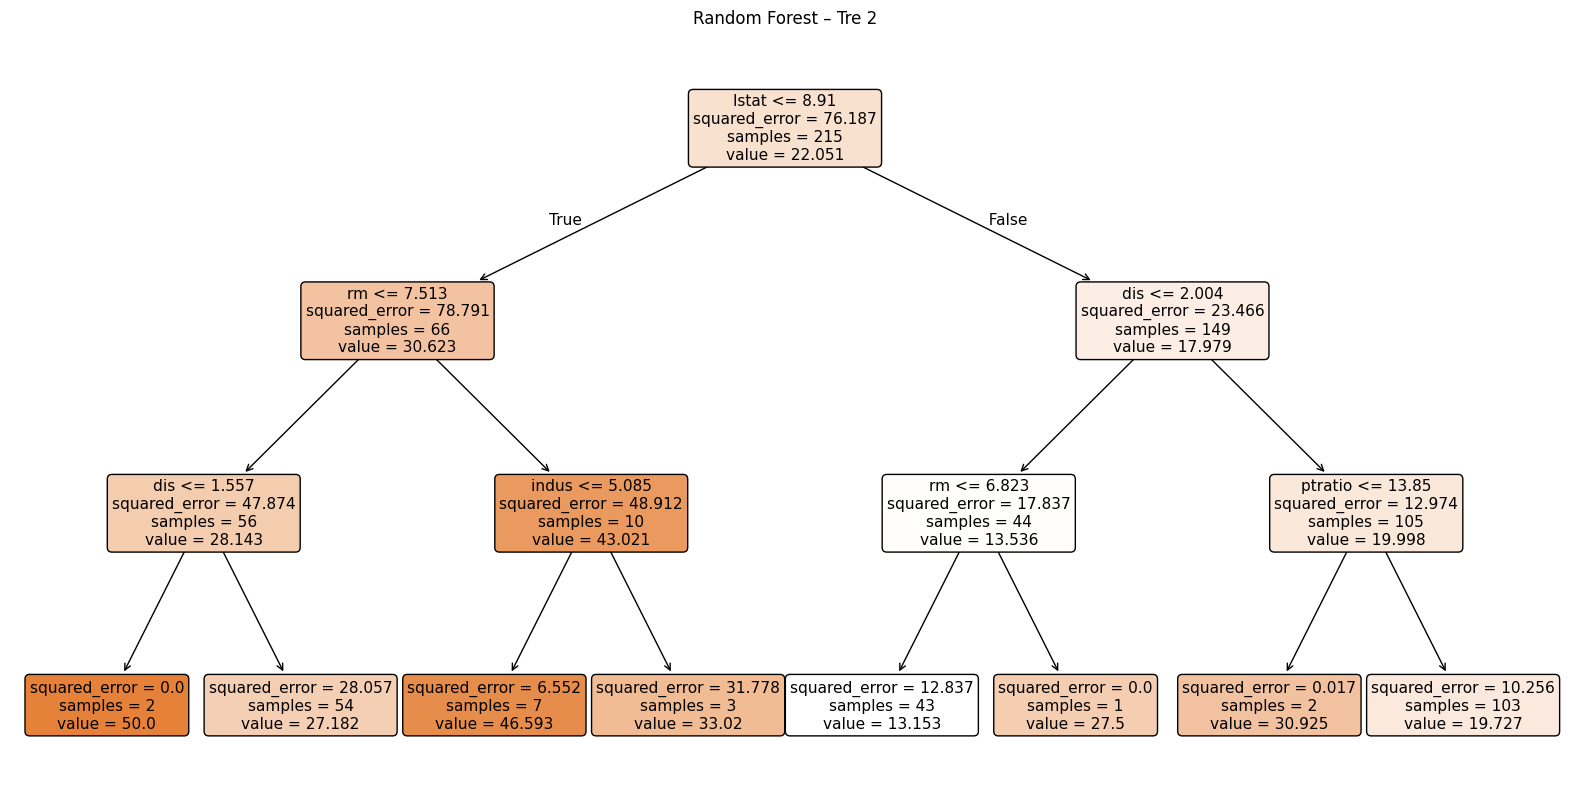

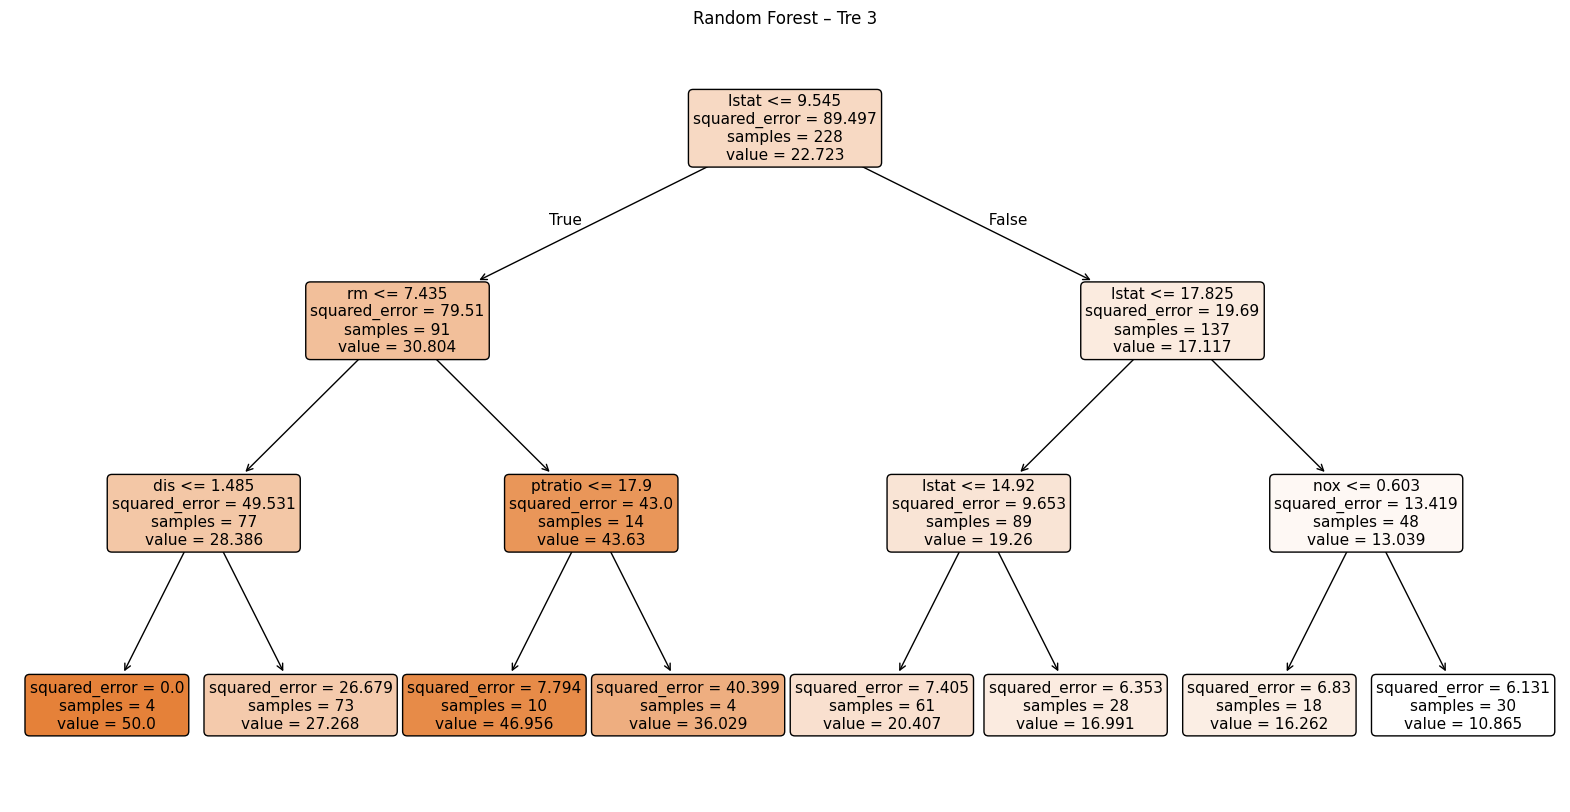

In [61]:
rf = RandomForestRegressor(
    n_estimators=3,   # lite antall for visualisering
    max_depth=3,
    random_state=1
)
rf.fit(X_train, y_train)

for i, tree in enumerate(rf.estimators_):
    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=X.columns,
        filled=True,
        rounded=True
    )
    plt.title(f"Random Forest – Tre {i + 1}")
    plt.show()

In [62]:
results = pd.DataFrame({
    "Modell": ["Lineær regresjon", "Beslutningstre", "Random Forest"],
    "Test MSE": [mse_lr, mse_tree, mse_rf]
})

results


,Modell,Test MSE
0,Lineær regresjon,20.881780
1,Beslutningstre,12.401832
2,Random Forest,8.474953
